# Hausse de loyer Équinoxe : notebook de départ

**Votre tâche : estimer la hausse de loyer d'Équinoxe pour 2026.**

Ce notebook vous aide à vous orienter et vous montre une méthode correcte. Les prévisions, les données externes et les décisions de jugement
vous reviennent. Si c'est la première fois que vous utilisez un notebook, pas d'inquiétude. C'est un outil très simple à utiliser et puissant, qui rend les flux de travail clairs et faciles à communiquer. Il est couramment utilisé
en apprentissage profond, et le maîtriser vous aidera énormément si vous vous dirigez un jour vers la science des données ou tout autre domaine analytique. **CTRL/COMMAND + MAJ + H** affiche les raccourcis. Apprenez à supprimer, restaurer, créer et exécuter des cellules. Ça vous aidera.

Lisez les cellules, ne vous contentez pas de les exécuter.

#### Important : vous verrez que la description des données ne correspond pas toujours parfaitement à ce qu'elles sont réellement. Dans ce cas-ci, PromoPay dans les concessions est décrit comme un frais mensuel, ce qui n'est pas du tout le cas. C'est assez facile à comprendre : si la promo égalait le loyer, le résident habiterait en pratique gratuitement.
##### Votre travail consiste aussi à découvrir ce que les données représentent réellement, et à les renommer selon votre propre description. Il n'y a pas de réponse unique.

## 1. Charger les données

## 1b. Lire les colonnes : champs `h` et champs `s`

Chaque colonne de ce jeu commence par **`h`** ou **`s`**. C'est la convention de Yardi, et
se tromper là-dessus est la façon la plus courante de corrompre une requête de gestion immobilière.

| préfixe | signification | exemple | à quoi ça sert |
|---|---|---|---|
| **`h`** | **handle** (identifiant) - une clé numérique | `hUnit`, `hProperty`, `hBuilding` | **les jointures**. Opaque, stable, unique. |
| **`s`** | **stored value** (valeur stockée) - ce qu'un humain lit | `sUnitCode`, `sRent`, `sBuilding` | **l'affichage et le regroupement**. |

Yardi conserve les deux moitiés d'une même information côte à côte - `hAgent` à côté de `sAgent`,
`hProperty` à côté de `sPropCode`. Elles ne sont **pas interchangeables** :

> **Joindre sur `h`. Étiqueter avec `s`.**

Ce n'est pas du pinaillage, c'est tout l'objet de la section 4 ci-dessous. `sUnitCode` vaut `"0203"` - et
trois appartements différents sur un même site portent cette même chaîne. `hUnit` est unique par
construction. Si vous associez une unité à elle-même du côté `s`, vous fusionnez des appartements sans le savoir;
si vous associez sur `hUnit`, c'est impossible.

**Deux mises en garde sur `s`, qui reflètent toutes deux le vrai comportement de Yardi, pas des particularités de ce jeu :**

1. **`s` ne veut pas dire « string ».** La table `UNIT` de Yardi stocke `SRENT` et `DSQFT` comme
   *valeurs numériques*. Ici, `sRent` et `sSqft` sont des nombres. Ne déduisez pas un type d'un préfixe -
   vérifiez-le.
2. **Le vrai Yardi subdivise davantage le côté `s`** - `dt*` pour les dates (`dtLeaseFrom`), `d*`
   pour les doubles (`dSqft`), `i*` pour les entiers, `b*` pour les indicateurs. Ce jeu les ramène tous
   à `s` pour garder l'attention sur la distinction `h` / `s`. Quand vous ouvrirez la vraie base de données, attendez-vous
   à un alphabet plus long.

### Les codes de frais

`sChargeCode` dans le fichier des concessions correspond au plan comptable de Yardi. Les codes semblent abîmés
parce que `sCode` est un `nchar(8)` - « Free other » devient `Freeothe`, « Referencing » devient
`Referenc`. Huit caractères, tronqués, avec une casse incohérente. C'est à ça que ressemblent les vrais.

| `sChargeCode` | `sChargeDesc` | ce que c'est réellement |
|---|---|---|
| `PromoPay` | Promo - Payable in the future | Un rabais promotionnel. **Lisez la mise en garde ci-dessous.** |
| `freerent` | Free rent | Loyer annulé pour une partie du bail. |
| `freepark` | Free Parking | Frais de stationnement annulés. Un avantage *accessoire*, pas du loyer. |
| `freelock` | Free Locker | Casier de rangement offert. Accessoire. |
| `freeappl` | Free Appliances | Frais d'électroménagers annulés. Accessoire. |
| `Freeothe` | Free other | Tout ce qui n'est pas catégorisé. À traiter avec méfiance. |
| `Indem` | Client indemnity | Un paiement versé au résident, par exemple pour régler un différend. |
| `Referenc` | Referencing program | Un crédit de référencement. |

**Celui qu'il faut examiner avant de s'y fier :** `PromoPay` est décrit comme un frais
mensuel. Ce n'en est pas un. Il est très majoritairement inscrit sur un seul mois, pour un montant proche d'un mois
de loyer complet. Prenez la description au pied de la lettre et vous conclurez que les résidents habitent
presque gratuitement. Comparez `sMonths` et la taille de `sAmount` à `sRent` avant de le modéliser -
et décidez vous-même comment l'étaler sur la durée du bail.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

listings   = pd.read_csv("data/equinoxe_listings.csv")
leases     = pd.read_csv("data/equinoxe_lease_history.csv")
concessions= pd.read_csv("data/equinoxe_concessions.csv")
asking     = pd.read_csv("data/equinoxe_asking_history.csv")

for name, df in [("listings", listings), ("leases", leases),
                 ("concessions", concessions), ("asking", asking)]:
    print(f"{name:<12} {len(df):>6,} lignes   {df.shape[1]:>2} colonnes")

listings      1,061 lignes   29 colonnes
leases        4,302 lignes   35 colonnes
concessions   3,560 lignes   18 colonnes
asking        3,857 lignes   14 colonnes


In [2]:
# Convertir les dates une seule fois, dès le départ.
for col in ["sLeaseFrom", "sLeaseTo", "sSignDate", "sAvailable"]:
    if col in leases.columns:
        leases[col] = pd.to_datetime(leases[col], errors="coerce")

leases["year"] = leases.sLeaseFrom.dt.year
asking["date"] = pd.to_datetime(asking.sMonth + "-01")

leases.head(3)

,hProperty,hUnit,hBuilding,sPropCode,sUnitCode,sBuilding,sCity,sState,sAddr1,sLatitude,sLongitude,sLeaseTerm,sPropType,sRent,sBeds,sBaths,sSqft,sLink,sFurnishing,sAvailable,sSmoking,sCats,sDogs,sRentEffective,sConcession,sSite,sUnitSubtype,sUnitType,sSignDate,sLeaseFrom,sLeaseTo,sTermMonths,sTermSeq,sRenewal,sFloor,year
0,100,4001,11,carlyle,0102,Le Carlyle,Mont-Royal,Quebec,815 Av. Plymouth,45.505554,-73.661842,Long Term,Apartment,1070,1,1.0,530,/rental/qc/mont-royal/carlyle/0102,Unfurnished,2023-04-01,Non-Smoking,True,True,993.08,1,le-carlyle,1 Bed,1_1d,2023-01-24,2023-04-01,2024-03-30,12.0,1,0,1,2023
1,100,4001,11,carlyle,0102,Le Carlyle,Mont-Royal,Quebec,815 Av. Plymouth,45.505554,-73.661842,Long Term,Apartment,1110,1,1.0,530,/rental/qc/mont-royal/carlyle/0102,Unfurnished,2024-05-27,Non-Smoking,True,True,1020.93,1,le-carlyle,1 Bed,1_1d,2024-05-09,2024-05-27,2025-05-26,12.0,2,1,1,2024
2,100,4001,11,carlyle,0102,Le Carlyle,Mont-Royal,Quebec,815 Av. Plymouth,45.505554,-73.661842,Negotiable,Apartment,1180,1,1.0,530,/rental/qc/mont-royal/carlyle/0102,Unfurnished,2025-05-27,Non-Smoking,True,True,1048.12,1,le-carlyle,1 Bed,1_1d,2025-04-26,2025-05-27,2026-05-26,12.0,3,1,1,2025


## 2. Ce que vous avez sous les yeux

Six immeubles répartis entre Laval, Mont-Royal, Ottawa et Pointe-Claire. Tout est en date du **2025-12-31**;
il n'y a pas de 2026 dans ce jeu, parce que 2026 est justement ce que vous prédisez.

Cinq sont au Québec et un, The Met, est en Ontario. Ce n'est pas
un détail : les deux provinces encadrent les hausses de loyer selon des régimes différents, et
les traiter comme un seul portefeuille est un choix de modélisation que vous devrez défendre.

**Une chose à bien comprendre avant de commencer.** Il s'agit d'un *extrait publié*, pas du
portefeuille. Il contient une part fixe des unités de chaque immeuble et de chaque type de chambre - la
répartition est représentative, les volumes ne le sont pas. Donc tout ce qui nécessite un dénominateur d'unités
réelles est hors de portée ici : **l'occupation, l'inoccupation, l'absorption et le rôle de loyers total du portefeuille
ne peuvent pas être calculés à partir de ce jeu, et un chiffre que vous en tireriez serait un artefact de
l'extrait plutôt qu'un fait sur l'entreprise.** C'est la *variation* des loyers que ces données permettent de mesurer,
et c'est la variation des loyers qu'on vous demande.

In [3]:
print(listings.groupby(["sState", "sCity", "sBuilding"]).size().to_string())
print()
print(listings.groupby(["sBeds", "sBaths"])
      .agg(units=("sRent", "size"),
           median_rent=("sRent", "median"),
           median_sqft=("sSqft", "median"))
      .to_string())

sState   sCity          sBuilding     
Ontario  Ottawa         The Met           124
Quebec   Laval          Daniel-Johnson    134
                        Levesque           84
                        Saint-Elzear      361
         Mont-Royal     Le Carlyle        192
         Pointe-Claire  Westpark          166

              units  median_rent  median_sqft
sBeds sBaths                                 
0     1.0        49       2565.0        550.0
1     1.0       350       1380.0        600.0
2     1.0       358       2440.0       1150.0
      2.0       281       2605.0       1265.0
3     1.0         2       2687.5       1597.5
      2.0        20       3237.5       1545.0
      3.0         1       4115.0       1905.0


## 3. L'approche évidente

Le premier réflexe naturel : le loyer médian par année.

In [4]:
naive = (leases[leases.year.between(2019, 2025)]
         .groupby("year")
         .agg(leases=("sRent", "size"), median_rent=("sRent", "median")))
naive["yoy_pct"] = (naive.median_rent.pct_change() * 100).round(2)
naive

,leases,median_rent,yoy_pct
year,,,
2019,328,1730.0,NaN
2020,373,1775.0,2.60
2021,361,1850.0,4.23
2022,422,1912.5,3.38
2023,693,2120.0,10.85
2024,902,2215.0,4.48
2025,958,2305.0,4.06


Selon ce tableau, les loyers auraient augmenté de **10,8 % en 2023**. Ce n'est pas le cas.

La médiane bouge dès que la *composition* bouge, et la composition a beaucoup bougé. Plusieurs
immeubles ont été mis en service en 2023 et 2024. Regardez ce qui se passe sous la
médiane :

In [5]:
window = leases[leases.year.between(2019, 2025)]
mix = window.groupby("year").agg(
    leases=("sRent", "size"),
    median_sqft=("sSqft", "median"),
    pct_2bed_plus=("sBeds", lambda s: (s >= 2).mean() * 100),
    buildings=("sBuilding", "nunique"))
mix["rent_per_sqft"] = (window.assign(psf=window.sRent / window.sSqft)
                        .groupby("year").psf.median())
mix.round(2)

,leases,median_sqft,pct_2bed_plus,buildings,rent_per_sqft
year,,,,,
2019,328,1177.5,78.66,3,1.48
2020,373,1180.0,77.75,3,1.53
2021,361,1175.0,78.39,3,1.60
2022,422,1160.0,72.51,3,1.71
2023,693,1095.0,62.63,5,2.04
2024,902,1045.0,62.20,6,2.20
2025,958,1025.0,60.23,6,2.33


In [6]:
# À partir de quand chaque sBuilding a-t-il commencé à générer des baux?
print(window.groupby("sBuilding").year.min().sort_values().to_string())
print()
# Et combien demandent-ils? (baux de 2024)
print(window[window.year == 2024].groupby("sBuilding")
      .agg(leases=("sRent", "size"), median_rent=("sRent", "median"))
      .sort_values("median_rent").to_string())

sBuilding
Daniel-Johnson    2019
Levesque          2019
Saint-Elzear      2019
Le Carlyle        2023
The Met           2023
Westpark          2024

                leases  median_rent
sBuilding                          
Levesque            84       1672.5
Daniel-Johnson     136       1870.0
Saint-Elzear       215       2145.0
Westpark           144       2202.5
Le Carlyle         195       2350.0
The Met            128       2752.5


Les unités louées en 2024 sont **plus petites** que celles louées en 2021 : la superficie
médiane est passée de 1 175 à 1 045 pi², et pourtant le loyer médian a fortement augmenté. C'est
le contraire de ce que la taille seule laisserait prévoir. La part des baux de 2 chambres et plus
est passée de 78 % à 62 % sur la même période.

Ce qui s'est réellement passé : Le Carlyle, The Met et Westpark ont été mis en service en 2023 et 2024. Ce sont des
immeubles haut de gamme, qui louent des unités plus petites, davantage axées sur les 1 chambre, à des tarifs au pied carré
bien plus élevés - la médiane 2024 de The Met est de 2 752 $, contre 1 672 $ pour Lévesque.
Le loyer au pied carré est passé de 1,71 $ à 2,20 $ en deux ans, et presque rien de
cela ne vient d'un locataire existant qui paie plus.


## 4. La méthode qui fonctionne : comparer une unité à elle-même

Associez les baux consécutifs de chaque unité et annualisez la variation. Même appartement,
même immeuble, tout pareil : ce qui reste, c'est le prix.

**La seule chose à ne pas rater :** associez sur `sPropCode` + `sUnitCode`.
Pas sur `sSite` + `sUnitCode`. Plusieurs sites regroupent plus d'un code de propriété avec
des numéros d'unité qui se chevauchent, et **248 des 1 061 unités entrent en collision** si vous utilisez
le site comme clé. Exécutez la cellule suivante pour le constater, puis utilisez `sPropCode` + `sUnitCode`, ou
la colonne `sLink`, qui est construite sur la clé sûre.

In [7]:
# Pourquoi sSite + sUnitCode n'est pas une clé : un site, un numéro d'unité, plusieurs appartements.
# (hUnit est l'identifiant qui EST unique - voir le dictionnaire de données plus haut.)
dupes = listings[listings.duplicated(["sSite", "sUnitCode"], keep=False)]
print(f"{len(dupes):,} unités sur {len(listings):,} entrent en collision sur sSite + sUnitCode")
print()
print(listings[(listings.sSite == "saint-elzear") & (listings.sUnitCode == "0203")]
      [["hUnit", "sSite", "sPropCode", "sUnitCode", "sBeds", "sBaths", "sSqft", "sRent"]]
      .to_string(index=False))

248 unités sur 1,061 entrent en collision sur sSite + sUnitCode

 hUnit        sSite sPropCode sUnitCode  sBeds  sBaths  sSqft  sRent
  5194 saint-elzear    stelz1      0203      2     1.0   1150   2415
  5350 saint-elzear    stelz2      0203      2     1.0   1245   2315
  5527 saint-elzear    stelz3      0203      2     1.0   1295   2385


In [8]:
UNIT_KEY = ["sPropCode", "sUnitCode"]      # <-- pas ["sSite", "sUnitCode"]

def same_unit_growth(df, price_col="sRent", date_col="sLeaseFrom",
                     min_gap=0.5, max_gap=2.5):
    """Variation annualisée du loyer, en comparant chaque unité à son propre bail précédent.

    Conserve les écarts entre `min_gap` et `max_gap` années : plus court signifie
    généralement le même bail enregistré deux fois, plus long est trop ancien pour une comparaison équivalente.
    """
    d = df.sort_values(UNIT_KEY + [date_col]).copy()
    d["prev_price"] = d.groupby(UNIT_KEY)[price_col].shift(1)
    d["prev_date"]  = d.groupby(UNIT_KEY)[date_col].shift(1)
    d = d.dropna(subset=["prev_price", "prev_date"])

    d["gap_years"] = (d[date_col] - d.prev_date).dt.days / 365.25
    d = d[d.gap_years.between(min_gap, max_gap, inclusive="neither")]
    d = d[(d.prev_price > 0) & (d[price_col] > 0)]

    d["growth_pct"] = ((d[price_col] / d.prev_price) ** (1 / d.gap_years) - 1) * 100
    return d

pairs = same_unit_growth(leases)
print(f"{len(pairs):,} paires utilisables sur {pairs.groupby(UNIT_KEY).ngroups:,} unités")

honest = (pairs[pairs.year.between(2021, 2025)]
          .groupby("year")
          .growth_pct.agg(pairs="size", median="median").round(2))
honest

3,179 paires utilisables sur 890 unités


,pairs,median
year,,
2021,355,4.46
2022,352,5.40
2023,416,2.29
2024,698,3.39
2025,780,7.04


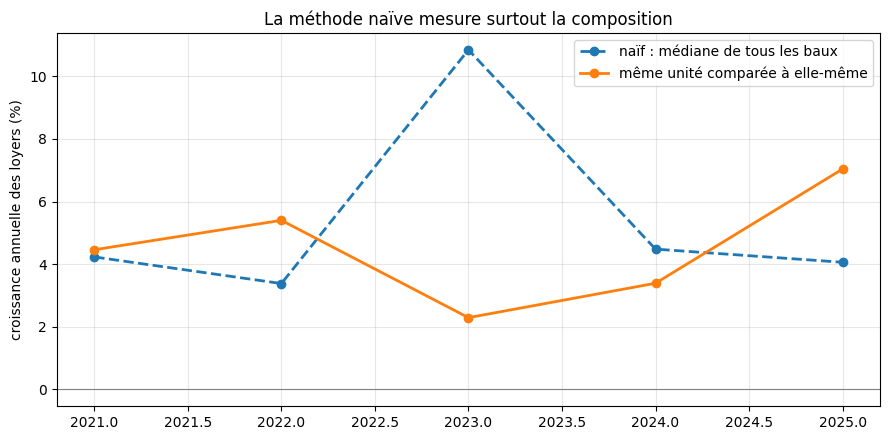

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
yrs = range(2021, 2026)
ax.plot(yrs, naive.loc[yrs, "yoy_pct"], "o--", label="naïf : médiane de tous les baux", lw=2)
ax.plot(yrs, honest.loc[yrs, "median"], "o-", label="même unité comparée à elle-même", lw=2)
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylabel("croissance annuelle des loyers (%)")
ax.set_title("La méthode naïve mesure surtout la composition")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



## 5. Loyer contractuel n'est pas loyer perçu

`sRent` est ce que le bail indique. `sRentEffective` est ce qu'Équinoxe a réellement
perçu après les mois gratuits, le stationnement gratuit et les casiers gratuits. Les concessions sont maintenant
la norme, et elles progressent.

In [10]:
conc = (leases[leases.year.between(2021, 2025)]
        .groupby("year")
        .agg(leases=("sRent", "size"),
             pct_with_concession=("sConcession", lambda s: s.mean() * 100),
             median_contracted=("sRent", "median"),
             median_effective=("sRentEffective", "median")))
conc["gap_pct"] = ((conc.median_effective / conc.median_contracted - 1) * 100)
conc.round(2)

,leases,pct_with_concession,median_contracted,median_effective,gap_pct
year,,,,,
2021,361,54.02,1850.0,1785.00,-3.51
2022,422,57.35,1912.5,1835.00,-4.05
2023,693,54.26,2120.0,2025.40,-4.46
2024,902,73.06,2215.0,2084.46,-5.89
2025,958,85.39,2305.0,2105.59,-8.65


In [11]:
# La concession change-t-elle l'évolution, ou seulement le niveau?
eff = same_unit_growth(leases, price_col="sRentEffective")
compare = pd.DataFrame({
    "contracted": honest["median"],
    "effective":  eff[eff.year.between(2021, 2025)].groupby("year").growth_pct.median(),
}).round(2)
compare

,contracted,effective
year,,
2021,4.46,3.54
2022,5.40,4.59
2023,2.29,2.02
2024,3.39,1.77
2025,7.04,3.58


Ces deux colonnes évoluent de près jusqu'en 2023 - à moins
d'un point l'une de l'autre - puis elles divergent : en 2025, la croissance contractuelle est de
7,0 % alors que la croissance effective est de 3,6 %. L'écart de *niveau* du tableau précédent
se creuse tout au long de la période.

Elles répondent à des questions différentes, et l'année où elles se séparent est celle où les concessions
deviennent plus importantes plutôt que simplement plus fréquentes. Si vous pouvez expliquer ce que cette séparation signifie pour un
propriétaire - et laquelle des deux vous citeriez à un propriétaire - vous comprenez les données
mieux que la plupart des équipes.

## 6. Les renouvellements ne se comportent pas comme les relocations

`sRenewal = 1`, c'est un locataire en place qui renouvelle. `sRenewal = 0`, c'est une unité
qui se libère et qui est relouée au prix du marché. Au Québec, ces deux cas sont régis par
des règles différentes, et l'écart entre les deux est toute la raison pour laquelle un propriétaire s'intéresse
à ce chiffre. Remarquez que l'écart change de camp au cours de la période : les renouvellements mènent en 2022, les relocations en 2025.

In [12]:
split = (pairs[pairs.year.between(2022, 2025)]
         .groupby(["year", "sRenewal"])
         .growth_pct.agg(pairs="size", median="median").round(2)
         .unstack("sRenewal"))
split.columns = [f"{a}_{'renewal' if b else 'turnover'}" for a, b in split.columns]
split

,pairs_turnover,pairs_renewal,median_turnover,median_renewal
year,,,,
2022,126,226,4.22,5.69
2023,177,239,1.85,2.58
2024,276,422,4.85,2.94
2025,307,473,8.98,6.41


## 7. À vous de jouer

Tout ce qui précède est descriptif. Rien de tout ça n'est une prévision, et 2026 n'est pas dans
ce jeu. Ce qui reste, c'est le vrai travail :

**a) Décidez à quelle question vous répondez.** « La hausse de loyer de l'année », ce sont en fait
plusieurs chiffres différents : même unité contractuel, même unité effectif, renouvellements
seulement, relocations seulement, portefeuille combiné. Ils ne concordent pas. Choisissez-en un, nommez-le dans
votre rapport et justifiez votre choix.

**b) Intégrez des données publiques.**

- **Enquête sur les logements locatifs de la SCHL** : loyers et taux d'inoccupation par nombre de chambres pour les
  RMR de Montréal et d'Ottawa, ainsi que la répartition entre logements ayant changé de locataire ou non, qui correspond
  directement à `sRenewal`
- **IPC de Statistique Canada**, composante loyers, Québec et Ontario
- **Tribunal administratif du logement** : les paramètres annuels d'augmentation de loyer au Québec.
  Cinq des six immeubles y sont assujettis
- **Taux légal d'augmentation des loyers en Ontario** : s'applique à l'immeuble The Met, selon
  des règles différentes. N'appliquez pas le plafond d'une province à l'autre

Utilisez la série externe sur l'inoccupation comme *contexte* pour l'orientation des loyers. N'essayez pas
de la transposer en taux d'occupation propre à ce portefeuille - voir la note de la section 2.

**c) Faites une prévision.** Une extrapolation de tendance est un point de départ légitime. Une approche
qui concilie la tendance interne avec le marché externe est meilleure. Énoncez
vos hypothèses.

**e) Misez sur le raisonnement et faites de votre mieux.** Si votre méthode atteint une précision de 95 % et que quelqu'un d'autre obtient 96 %, ça ne veut pas dire que l'autre a gagné. Vous êtes évalué davantage sur la technique que sur le résultat. Les résultats comptent, mais sans un raisonnement constamment démontré derrière chaque choix, même 99 % ne veut rien dire. Nous devons voir une logique claire derrière vos décisions. Note : vous devez **TOUJOURS** expliquer une étape importante, même si ça vous semble inutile ou peu naturel.

### 7a. Headline definition and scope

Our target is the **median annualized effective-rent growth across consecutive
same-unit lease pairs**, grouped by the **newer lease's start year**, combining
renewals and turnovers. `sRentEffective` includes the economic concession
adjustments recorded by the CRM. It is not a measure of cash collected each month
or growth in total portfolio revenue.

### 7b. Prepare analysis copies and validate types

The loader converts lease dates but not concession dates. The failing subtraction
therefore tries to subtract strings. We convert concession dates and relevant
numeric fields **on analysis copies**, leaving the CSVs and starter variables
unchanged. Invalid nonmissing values stop with a column name and count rather than
silently disappearing. Missing concession values are reported and excluded from
the affected diagnostic; a missing start date cannot match a lease.


In [13]:
TARGET_PRICE_COL = "sRentEffective"
TARGET_NAME = "median annualized same-unit effective rent growth"
HISTORY_START_YEAR = 2021
HISTORY_END_YEAR = 2025
START_GAP_MIN_YEARS = 0.5
START_GAP_MAX_YEARS = 2.5

def prepare_analysis_inputs(lease_input, concession_input):
    lease_data = lease_input.copy()
    concession_data = concession_input.copy()
    specs = [
        ("leases", lease_data,
         ["hUnit", "sPropCode", "sUnitCode", "sLeaseFrom", "sLeaseTo",
          "sRent", "sRentEffective", "sTermMonths", "sRenewal", "sConcession"],
         ["sLeaseFrom", "sLeaseTo"],
         ["sRent", "sRentEffective", "sTermMonths", "sRenewal", "sConcession"]),
        ("concessions", concession_data,
         ["hUnit", "sChargeCode", "sChargeDesc", "sDateFrom", "sDateTo",
          "sAmount", "sMonths"],
         ["sDateFrom", "sDateTo"], ["sAmount", "sMonths"]),
    ]
    for name, frame, required, dates, numbers in specs:
        missing_columns = sorted(set(required) - set(frame.columns))
        if missing_columns:
            raise ValueError(f"{name}: missing columns {missing_columns}")
        for column in dates + numbers:
            original_values = frame[column]
            converted = (pd.to_datetime(original_values, errors="coerce")
                         if column in dates
                         else pd.to_numeric(original_values, errors="coerce"))
            invalid = original_values.notna() & converted.isna()
            if column in numbers:
                invalid |= converted.notna() & ~np.isfinite(converted)
            if invalid.any():
                raise ValueError(
                    f"{name}.{column}: {int(invalid.sum())} invalid values; "
                    "check parsing/source values before continuing."
                )
            frame[column] = converted

    lease_required = ["hUnit", "sPropCode", "sUnitCode", "sLeaseFrom", "sLeaseTo",
                      "sRent", "sRentEffective", "sTermMonths", "sRenewal", "sConcession"]
    if lease_data[lease_required].isna().any().any():
        raise ValueError("Required lease fields contain missing values; audit before pairing.")
    for flag in ["sRenewal", "sConcession"]:
        if not lease_data[flag].isin([0, 1]).all():
            raise ValueError(f"leases.{flag} must contain only 0 or 1.")
    if lease_data.duplicated(["hUnit", "sLeaseFrom"]).any():
        raise ValueError("Duplicate hUnit + sLeaseFrom; reconcile duplicate leases first.")
    if lease_data.duplicated(["sPropCode", "sUnitCode", "sLeaseFrom"]).any():
        raise ValueError("Duplicate unit key + sLeaseFrom; reconcile before same-unit pairing.")
    if (lease_data["sLeaseTo"] < lease_data["sLeaseFrom"]).any():
        raise ValueError("Lease end precedes lease start.")
    if (lease_data["sTermMonths"] <= 0).any():
        raise ValueError("Lease terms must be positive before amortizing concessions.")
    if (concession_data["sMonths"].dropna() < 0).any():
        raise ValueError("Negative concession duration; audit before reconciliation.")
    lease_data["year"] = lease_data["sLeaseFrom"].dt.year
    return lease_data, concession_data

analysis_leases, analysis_concessions = prepare_analysis_inputs(leases, concessions)
print("Concession missing values (counts):")
print(analysis_concessions[
    ["hUnit", "sDateFrom", "sDateTo", "sAmount", "sMonths"]
].isna().sum().to_string())


Concession missing values (counts):
hUnit        0
sDateFrom    0
sDateTo      0
sAmount      0
sMonths      0


In [14]:
target_pairs = same_unit_growth(
    analysis_leases, price_col=TARGET_PRICE_COL,
    min_gap=START_GAP_MIN_YEARS, max_gap=START_GAP_MAX_YEARS
)
target_history = (
    target_pairs[target_pairs.year.between(HISTORY_START_YEAR, HISTORY_END_YEAR)]
    .groupby("year").growth_pct.agg(pairs="size", median="median")
)
# Keep full precision in variables; round only for display.
target_history.round(2)


,pairs,median
year,,
2021,355,3.54
2022,352,4.59
2023,416,2.02
2024,698,1.77
2025,780,3.58


### 7c. Renewals, turnovers, and contractual vs effective growth

Use `sRenewal` as recorded in the CRM, not inferred from lease gaps. The table
shows pair counts and the renewal share, so claims about a stable lease-type mix
can be checked. A reversal in growth rankings does not by itself establish a
cause or a structural break.

For contractual/effective comparisons, retain the **same eligible lease pairs**
for both measures and report their count. `gap_pp` is a difference between group
medians in percentage points, not the median of pairwise differences.


In [15]:
target_by_lease_type = (
    target_pairs[target_pairs.year.between(HISTORY_START_YEAR, HISTORY_END_YEAR)]
    .assign(lease_type=lambda d: d["sRenewal"].map({0: "turnover", 1: "renewal"}))
    .groupby(["year", "lease_type"]).growth_pct
    .agg(pairs="size", median="median")
)
lease_type_counts = target_by_lease_type["pairs"].unstack("lease_type", fill_value=0)
lease_type_counts = lease_type_counts.reindex(columns=["renewal", "turnover"], fill_value=0)
lease_type_counts["renewal_share_pct"] = (
    100 * lease_type_counts["renewal"]
    / lease_type_counts[["renewal", "turnover"]].sum(axis=1)
)
print(target_by_lease_type.round(2).to_string())
print("\nMix among eligible effective-rent pairs:")
print(lease_type_counts.round(2).to_string())


                 pairs  median
year lease_type               
2021 renewal       220    4.00
     turnover      135    2.36
2022 renewal       226    4.92
     turnover      126    3.40
2023 renewal       239    2.21
     turnover      177    1.68
2024 renewal       422    1.38
     turnover      276    2.75
2025 renewal       473    2.91
     turnover      307    5.74

Mix among eligible effective-rent pairs:
lease_type  renewal  turnover  renewal_share_pct
year                                            
2021            220       135              61.97
2022            226       126              64.20
2023            239       177              57.45
2024            422       276              60.46
2025            473       307              60.64


In [16]:
contractual_pairs = same_unit_growth(
    analysis_leases, price_col="sRent",
    min_gap=START_GAP_MIN_YEARS, max_gap=START_GAP_MAX_YEARS
)
pair_key = UNIT_KEY + ["sLeaseFrom"]
comparison_pairs = target_pairs.merge(
    contractual_pairs[pair_key + ["growth_pct"]]
    .rename(columns={"growth_pct": "contractual_growth_pct"}),
    on=pair_key, how="inner", validate="one_to_one"
)
print(f"Common pairs: {len(comparison_pairs):,}; "
      f"effective eligible: {len(target_pairs):,}; "
      f"contractual eligible: {len(contractual_pairs):,}")
rent_type_comparison = (
    comparison_pairs[
        comparison_pairs.year.between(HISTORY_START_YEAR, HISTORY_END_YEAR)
    ]
    .assign(lease_type=lambda d: d["sRenewal"].map({0: "turnover", 1: "renewal"}))
    .groupby(["year", "lease_type"])
    .agg(pairs=("growth_pct", "size"),
         contractual=("contractual_growth_pct", "median"),
         effective=("growth_pct", "median"))
)
rent_type_comparison["gap_pp"] = (
    rent_type_comparison["contractual"] - rent_type_comparison["effective"]
)
rent_type_comparison.round(2)


Common pairs: 3,179; effective eligible: 3,179; contractual eligible: 3,179


pairs  contractual  effective  gap_pp
year lease_type                                       
2021 renewal       220         4.77       4.00    0.77
     turnover      135         3.52       2.36    1.16
2022 renewal       226         5.69       4.92    0.76
     turnover      126         4.22       3.40    0.81
2023 renewal       239         2.58       2.21    0.36
     turnover      177         1.85       1.68    0.17
2024 renewal       422         2.94       1.38    1.56
     turnover      276         4.85       2.75    2.11
2025 renewal       473         6.41       2.91    3.50
     turnover      307         8.98       5.74    3.24

### 7d. Inspect concession amounts, durations, and signs

`date_span_days` is the elapsed difference between end and start, **not** an
inclusive billing duration or a replacement for `sMonths`. Negative spans are
reported for investigation. Normalize charge codes for comparisons, but keep
the original labels. Missing codes do not crash the PromoPay selection.

PromoPay is not assumed to recur monthly: inspect its amount and duration.
Accessory benefits and other credits may follow different conventions; the
two formulas below are exploratory accounting hypotheses.


In [17]:
analysis_concessions["date_span_days"] = (
    analysis_concessions["sDateTo"] - analysis_concessions["sDateFrom"]
).dt.days
print("Negative concession date spans:",
      int(analysis_concessions["date_span_days"].lt(0).sum()))
concession_type_summary = (
    analysis_concessions
    .groupby(["sChargeCode", "sChargeDesc"], dropna=False)
    .agg(records=("hUnit", "size"), units=("hUnit", "nunique"),
         amount_min=("sAmount", "min"), amount_median=("sAmount", "median"),
         amount_max=("sAmount", "max"), months_min=("sMonths", "min"),
         months_median=("sMonths", "median"), months_max=("sMonths", "max"),
         span_days_median=("date_span_days", "median"),
         first_date=("sDateFrom", "min"), last_date=("sDateTo", "max"))
    .sort_values("records", ascending=False)
)
print(concession_type_summary.round(2).to_string())
print("\nAmount sign by charge code (missing amounts counted separately):")
print(analysis_concessions.groupby("sChargeCode", dropna=False).agg(
    negative=("sAmount", lambda x: x.lt(0).sum()),
    zero=("sAmount", lambda x: x.eq(0).sum()),
    positive=("sAmount", lambda x: x.gt(0).sum()),
    missing=("sAmount", lambda x: x.isna().sum())
).to_string())
promopay_mask = (
    analysis_concessions["sChargeCode"].astype("string")
    .str.strip().str.casefold().eq("promopay").fillna(False)
)
print("\nPromoPay sMonths distribution:")
print(analysis_concessions.loc[promopay_mask, "sMonths"]
      .value_counts(dropna=False).sort_index().to_string())


Negative concession date spans: 0
                                           records  units  amount_min  amount_median  amount_max  months_min  months_median  months_max  span_days_median first_date  last_date
sChargeCode sChargeDesc                                                                                                                                                        
PromoPay    Promo - Payable in the future     1494    781   -10927.95       -1356.60      -12.68         1.0            1.0         2.0              29.0 2017-08-01 2027-03-30
freepark    Free Parking                      1006    646    -1739.90        -150.50       -1.99         3.0           12.0        23.0             364.0 2017-01-01 2027-05-01
Freeothe    Free other                         570    436    -1587.27        -153.49       -2.90         3.0           12.0        12.0             364.0 2017-01-01 2027-03-31
freelock    Free Locker                        175    166    -1757.60        -139.35  

### 7e. Diagnostic concession-to-lease linkage

Candidate rule: same `hUnit`, with concession start inside the inclusive lease
window. This is a **diagnostic heuristic**, not proof of lease attribution: a credit
may be booked before/after the lease, or extend beyond it. Report zero, one and
multiple matches. Use stable positional concession IDs independent of the input
DataFrame index. Keep the candidate expansion internal; print aggregates only.


In [18]:
concession_rows = analysis_concessions[
    ["hUnit", "sChargeCode", "sChargeDesc", "sDateFrom", "sDateTo", "sAmount", "sMonths"]
].reset_index(drop=True).copy()
concession_rows["concession_id"] = np.arange(len(concession_rows))
concession_candidates = concession_rows.merge(
    analysis_leases[["hUnit", "sLeaseFrom", "sLeaseTo"]],
    on="hUnit", how="left"
)
concession_candidates["date_match"] = (
    concession_candidates["sDateFrom"].between(
        concession_candidates["sLeaseFrom"], concession_candidates["sLeaseTo"],
        inclusive="both"
    ).fillna(False)
)
match_counts = (
    concession_candidates.loc[concession_candidates["date_match"]]
    .groupby("concession_id").size()
    .reindex(concession_rows["concession_id"], fill_value=0)
)
print("Lease matches per concession:")
print(match_counts.value_counts().sort_index().to_string())
print(f"\nExactly one match: {match_counts.eq(1).mean():.2%}")
print(f"No match:          {match_counts.eq(0).mean():.2%}")
print(f"Multiple matches:  {match_counts.gt(1).mean():.2%}")
link_check = (
    concession_rows.assign(uniquely_matched=match_counts.eq(1).to_numpy())
    .groupby("sChargeCode", dropna=False)
    .agg(records=("concession_id", "size"),
         unique_matches=("uniquely_matched", "sum"),
         unique_match_rate=("uniquely_matched", "mean"))
    .sort_values("records", ascending=False)
)
link_check["unique_match_rate"] *= 100
print("\nMatch rate by charge code (%):")
print(link_check.round(2).to_string())


Lease matches per concession:
0     204
1    3356

Exactly one match: 94.27%
No match:          5.73%
Multiple matches:  0.00%

Match rate by charge code (%):
             records  unique_matches  unique_match_rate
sChargeCode                                            
PromoPay        1494            1473              98.59
freepark        1006             915              90.95
Freeothe         570             519              91.05
freelock         175             167              95.43
freerent         166             151              90.96
Indem             69              62              89.86
freeappl          44              36              81.82
Referenc          36              33              91.67


### 7f. Reconcile only unambiguous, complete diagnostic groups

The previous code claimed to retain unique matches but did not apply that filter.
Here, **each retained concession must match exactly one lease**. We also exclude
any lease touched by an ambiguous matching concession, since retaining only its
other credits would produce an incomplete total. Missing amounts/durations or
reversed concession dates exclude the affected lease from this reconciliation.
Excluded counts are reported. Unmatched credits still limit coverage: this is
not proof that every lease-level concession has been captured.

Two signed-amount hypotheses are tested: (1) `sAmount * sMonths` is the total
credit, or (2) `sAmount` already is the total credit. Divide the credit by the
recorded positive `sTermMonths` and add it to contractual rent. **Do not replace
`sRentEffective` with either formula** without validating signs and charge-specific
semantics. A good fit is evidence, not a universal interpretation of every code.


In [19]:
LEASE_KEY = ["hUnit", "sLeaseFrom"]
unique_ids = match_counts.index[match_counts.eq(1)]
matched_concessions = concession_candidates.loc[
    concession_candidates["date_match"]
    & concession_candidates["concession_id"].isin(unique_ids)
].copy()
ambiguous_ids = match_counts.index[match_counts.gt(1)]
ambiguous_lease_keys = concession_candidates.loc[
    concession_candidates["date_match"]
    & concession_candidates["concession_id"].isin(ambiguous_ids), LEASE_KEY
].drop_duplicates()
incomplete_lease_keys = matched_concessions.loc[
    matched_concessions[["sAmount", "sMonths"]].isna().any(axis=1)
    | matched_concessions["sDateTo"].lt(matched_concessions["sDateFrom"]),
    LEASE_KEY
].drop_duplicates()
excluded_lease_keys = pd.concat(
    [ambiguous_lease_keys, incomplete_lease_keys], ignore_index=True
).drop_duplicates()
matched_index = pd.MultiIndex.from_frame(matched_concessions[LEASE_KEY])
excluded_index = pd.MultiIndex.from_frame(excluded_lease_keys[LEASE_KEY])
reconciliation_concessions = matched_concessions.loc[
    ~matched_index.isin(excluded_index)
].copy()
print("Unambiguously matched concession records:", len(matched_concessions))
print("Lease keys touched by ambiguous records:", len(ambiguous_lease_keys))
print("Lease keys with incomplete/invalid credit inputs:", len(incomplete_lease_keys))
print("Records retained for reconciliation:", len(reconciliation_concessions))

reconciliation_concessions["amount_x_months"] = (
    reconciliation_concessions["sAmount"] * reconciliation_concessions["sMonths"]
)
# Single aggregation; the earlier placeholder/duplicate aggregation was removed.
concessions_by_lease = (
    reconciliation_concessions.groupby(LEASE_KEY, as_index=False)
    .agg(n_concessions=("concession_id", "size"),
         concession_amount_sum=("sAmount", "sum"),
         concession_amount_x_months=("amount_x_months", "sum"))
)
reconciliation = concessions_by_lease.merge(
    analysis_leases[LEASE_KEY + ["sRent", "sRentEffective", "sTermMonths", "sRenewal"]],
    on=LEASE_KEY, how="left", validate="one_to_one"
)
reconciliation["pred_effective_monthly"] = (
    reconciliation["sRent"]
    + reconciliation["concession_amount_x_months"] / reconciliation["sTermMonths"]
)
reconciliation["pred_effective_onetime"] = (
    reconciliation["sRent"]
    + reconciliation["concession_amount_sum"] / reconciliation["sTermMonths"]
)
for interpretation in ["monthly", "onetime"]:
    reconciliation[f"error_{interpretation}"] = (
        reconciliation[f"pred_effective_{interpretation}"]
        - reconciliation["sRentEffective"]
    ).abs()
print("\nLeases retained for reconciliation:", len(reconciliation))
if reconciliation.empty:
    print("No eligible reconciliation groups; inspect linkage and missing-input diagnostics.")
else:
    print("\nAbsolute reconciliation error ($/month):")
    print(reconciliation[["error_monthly", "error_onetime"]]
          .describe(percentiles=[0.50, 0.75, 0.90, 0.95]).round(2).to_string())
    for tolerance in [1, 10]:
        print(f"\nShare within ${tolerance} of CRM effective rent:")
        for interpretation in ["monthly", "onetime"]:
            print(f"{interpretation}: "
                  f"{reconciliation[f'error_{interpretation}'].le(tolerance).mean():.2%}")


Unambiguously matched concession records: 3356
Lease keys touched by ambiguous records: 0
Lease keys with incomplete/invalid credit inputs: 0
Records retained for reconciliation: 3356

Leases retained for reconciliation: 2486

Absolute reconciliation error ($/month):
       error_monthly  error_onetime
count        2486.00        2486.00
mean           49.85          72.03
std            85.73          76.65
min             0.00           0.00
50%             0.00          51.67
75%            76.39         108.29
90%           159.89         182.91
95%           216.40         228.91
max          1232.16         532.28

Share within $1 of CRM effective rent:
monthly: 54.34%
onetime: 18.58%

Share within $10 of CRM effective rent:
monthly: 56.76%
onetime: 26.91%


### 7g. Concession trends, overall and by lease type

`rent_discount` is the monthly difference already recorded between contractual
and effective rent. Rates/counts use the CRM `sConcession` flag. Conditional
discount summaries use **flagged leases** (including any zero/negative discounts),
so their names and denominators agree. Positive-discount counts are shown
separately to reveal flag/discount disagreements. These counts are observed
leases, not occupancy or total portfolio units.


In [20]:
concession_trend = analysis_leases.copy()
concession_trend["rent_discount"] = (
    concession_trend["sRent"] - concession_trend["sRentEffective"]
)
concession_trend["discount_if_flagged"] = concession_trend["rent_discount"].where(
    concession_trend["sConcession"].eq(1)
)
concession_trend["positive_discount"] = concession_trend["rent_discount"].gt(0)
trend_window = concession_trend.loc[
    concession_trend["year"].between(HISTORY_START_YEAR, HISTORY_END_YEAR)
]

def summarize_concession_trends(frame, group_columns):
    summary = frame.groupby(group_columns).agg(
        leases=("hUnit", "size"),
        concession_leases=("sConcession", "sum"),
        concession_rate_pct=("sConcession", "mean"),
        positive_discount_leases=("positive_discount", "sum"),
        median_discount_all=("rent_discount", "median"),
        mean_discount_all=("rent_discount", "mean"),
        median_discount_if_concession=("discount_if_flagged", "median"),
        mean_discount_if_concession=("discount_if_flagged", "mean"),
    )
    summary["concession_rate_pct"] *= 100
    return summary

yearly_concessions = summarize_concession_trends(trend_window, ["year"])
print(yearly_concessions.round(2).to_string())
print("\nFlag/discount consistency (counts):")
print(pd.crosstab(concession_trend["sConcession"],
                  concession_trend["positive_discount"]).to_string())


      leases  concession_leases  concession_rate_pct  positive_discount_leases  median_discount_all  mean_discount_all  median_discount_if_concession  mean_discount_if_concession
year                                                                                                                                                                              
2021     361                195                54.02                       195                48.40              48.05                          88.75                        88.95
2022     422                242                57.35                       242                69.72              63.37                         109.84                       110.51
2023     693                376                54.26                       376                71.23              77.20                         142.19                       142.29
2024     902                659                73.06                       659               134.67      

In [24]:
concession_by_type = summarize_concession_trends(
    trend_window, ["year", "sRenewal"]
).reset_index()
concession_by_type["lease_type"] = concession_by_type["sRenewal"].map(
    {0: "turnover", 1: "renewal"}
)
print(concession_by_type[[
    "year", "lease_type", "leases", "concession_leases", "concession_rate_pct",
    "positive_discount_leases", "median_discount_all", "mean_discount_all",
    "median_discount_if_concession", "mean_discount_if_concession"
]].round(2).to_string(index=False))


 year lease_type  leases  concession_leases  concession_rate_pct  positive_discount_leases  median_discount_all  mean_discount_all  median_discount_if_concession  mean_discount_if_concession
 2021   turnover     136                 74                54.41                        74                48.77              47.11                          86.47                        86.58
 2021    renewal     225                121                53.78                       121                48.28              48.62                          91.65                        90.41
 2022   turnover     190                103                54.21                       103                58.08              57.17                         100.29                       105.46
 2022    renewal     232                139                59.91                       139                81.81              68.45                         112.97                       114.25
 2023   turnover     447                259  

## Minimal Forecasting

In [25]:
FORECAST_YEAR = 2026
BACKTEST_YEARS = [2023, 2024, 2025]


def historical_target(lease_data):
    """Return the yearly headline target from same-unit effective-rent pairs."""
    pairs = same_unit_growth(
        lease_data,
        price_col=TARGET_PRICE_COL,
        min_gap=START_GAP_MIN_YEARS,
        max_gap=START_GAP_MAX_YEARS,
    )

    return (
        pairs.groupby("year")["growth_pct"]
        .median()
        .sort_index()
    )


def persistence_forecast(lease_data, target_year):
    """Forecast target_year using the realized target from target_year - 1."""
    previous_year = target_year - 1
    cutoff = pd.Timestamp(previous_year, 12, 31)

    # Simulate what was available at the forecasting date.
    available_leases = lease_data.loc[
        lease_data["sLeaseFrom"] <= cutoff
    ].copy()

    history = historical_target(available_leases)

    if previous_year not in history.index:
        raise ValueError(
            f"No historical target available for {previous_year}."
        )

    return float(history.loc[previous_year])


def estimate_2026(leases, asking, external=None):
    """Estimate 2026 headline rent growth using the persistence baseline."""
    return persistence_forecast(leases, FORECAST_YEAR)


def backtest(leases, target_year):
    """Forecast target_year from prior information and compare with reality."""
    prediction = persistence_forecast(leases, target_year)

    actual_history = historical_target(leases)

    if target_year not in actual_history.index:
        raise ValueError(
            f"No realized target available for {target_year}."
        )

    actual = float(actual_history.loc[target_year])

    return {
        "year": target_year,
        "prediction_pct": prediction,
        "actual_pct": actual,
        "error_pp": prediction - actual,
        "absolute_error_pp": abs(prediction - actual),
    }

In [26]:
baseline_backtest = pd.DataFrame(
    [backtest(leases, year) for year in BACKTEST_YEARS]
).set_index("year")

baseline_mae = baseline_backtest["absolute_error_pp"].mean()
baseline_2026 = estimate_2026(leases, asking)

display(baseline_backtest.round(2))

print(
    f"\nPersistence baseline MAE: "
    f"{baseline_mae:.2f} percentage points"
)

print(
    f"2026 persistence estimate: "
    f"{baseline_2026:.2f}%"
)

,prediction_pct,actual_pct,error_pp,absolute_error_pp
year,,,,
2023,4.59,2.02,2.57,2.57
2024,2.02,1.77,0.25,0.25
2025,1.77,3.58,-1.80,1.80



Persistence baseline MAE: 1.54 percentage points
2026 persistence estimate: 3.58%


## 9. Three-year trailing-mean baseline

In [27]:
TRAILING_WINDOW_YEARS = 3


def trailing_mean_forecast(
    lease_data,
    target_year,
    window=TRAILING_WINDOW_YEARS,
):
    """Forecast using the mean target growth from the previous `window` years."""
    previous_year = target_year - 1
    cutoff = pd.Timestamp(previous_year, 12, 31)

    available_leases = lease_data.loc[
        lease_data["sLeaseFrom"] <= cutoff
    ].copy()

    history = historical_target(available_leases)

    recent_history = history.loc[
        history.index <= previous_year
    ].tail(window)

    if len(recent_history) < window:
        raise ValueError(
            f"Need {window} historical years before {target_year}, "
            f"but only found {len(recent_history)}."
        )

    return float(recent_history.mean())


def backtest_trailing_mean(leases, target_year):
    prediction = trailing_mean_forecast(
        leases,
        target_year,
    )

    actual_history = historical_target(leases)
    actual = float(actual_history.loc[target_year])

    return {
        "year": target_year,
        "prediction_pct": prediction,
        "actual_pct": actual,
        "error_pp": prediction - actual,
        "absolute_error_pp": abs(prediction - actual),
    }

In [28]:
trailing_backtest = pd.DataFrame(
    [
        backtest_trailing_mean(leases, year)
        for year in BACKTEST_YEARS
    ]
).set_index("year")

trailing_mae = trailing_backtest["absolute_error_pp"].mean()
trailing_2026 = trailing_mean_forecast(
    leases,
    FORECAST_YEAR,
)

display(trailing_backtest.round(2))

print(
    f"\n3-year mean baseline MAE: "
    f"{trailing_mae:.2f} percentage points"
)

print(
    f"2026 3-year mean estimate: "
    f"{trailing_2026:.2f}%"
)

print(
    f"\nPersistence MAE: {baseline_mae:.2f} pp"
)
print(
    f"3-year mean MAE: {trailing_mae:.2f} pp"
)

,prediction_pct,actual_pct,error_pp,absolute_error_pp
year,,,,
2023,3.72,2.02,1.70,1.70
2024,3.38,1.77,1.61,1.61
2025,2.79,3.58,-0.78,0.78



3-year mean baseline MAE: 1.36 percentage points
2026 3-year mean estimate: 2.46%

Persistence MAE: 1.54 pp
3-year mean MAE: 1.36 pp


In [22]:
# Gabarit -- à compléter.

def estimate_2026(leases, asking, external=None):
    """Retourne votre estimation de la hausse de loyer 2026, en pourcentage.

    Indiquez dans votre rapport à quelle définition vous répondez et pourquoi.
    """
    raise NotImplementedError


def backtest(leases, target_year):
    """Exécute votre méthode comme si vous étiez à la fin de target_year - 1,
    et compare le résultat avec ce qui s'est réellement passé en target_year."""
    raise NotImplementedError


# Première vérification suggérée une fois estimate_2026 fonctionnel :
# for yr in (2023, 2024, 2025):
#     print(yr, backtest(leases, yr))

## Ce qui rapporte des points

La méthode avant la proximité du résultat. Une équipe qui énonce sa définition, associe les mêmes unités sur
la bonne clé, traite les concessions explicitement et tombe un peu à côté
obtiendra une meilleure note qu'une équipe qui tombe plus près en faisant la moyenne de quelque chose qu'elle n'a jamais
examiné.

Plus précisément, rapportent des points :

- Nommer la définition à laquelle vous répondez
- Comparer les mêmes unités plutôt que des médianes d'une année à l'autre
- Repérer et expliquer le problème de composition
- Utiliser `sRentEffective`, ou justifier pourquoi vous avez utilisé le loyer contractuel
- Séparer les renouvellements des relocations
- Concilier les données de marché externes avec la tendance interne
- Valider votre propre méthode sur l'historique (backtest)

## Ce qui fait perdre des points :

- Les nombres magiques et les variables mal nommées. Restez cohérent dans votre logique de nommage.
- Utiliser `sSite` + `sUnitCode` comme clé pour comparer les mêmes unités
- Une mauvaise utilisation des variables (features).
- Citer un taux d'occupation, d'inoccupation ou d'absorption tiré de cet extrait
- Aucune cellule markdown

### Ce qui donne des points bonus :

- Traiter l'immeuble The Met selon les règles de l'Ontario.